# Estimate the effects of amino acid substitutions on fitness
$$
\left( \Delta s - W a \right)^\top C^{-1} \left( \Delta s - W a \right) + \lambda \lVert a \rVert_1
$$

$a$ describes the impact on fitness of specific amino acid substitutions. $W$ is the assignment of amino acid substitutions of pango lineages compared to their parent lineage, $C$ the diagonal covariance matrix between growth rate differences and $\Delta s$ the difference in growth rate between a pango lineage and its parent.

In [11]:
import pandas as pd
import numpy as np

import cvxpy as cp
from scipy.linalg import cholesky

from matplotlib import pyplot as plt

## Start with Toy Problem


In [19]:
n_variants = 20
n_aachanges = 10

def simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa=0.5, noise_level = 0.1):
    """
    Simulate a dataset of amino acid substitutions with a given number of variants and changes.
    """

    np.random.seed(0)
    true_a = np.zeros(n_aachanges)
    nonzero_indices = np.random.choice(n_aachanges, size=int(n_aachanges * percent_non0impact_aa), replace=False)
    true_a[nonzero_indices] = np.random.normal(loc=0, scale=0.1, size=len(nonzero_indices))

    W = (np.random.rand(n_variants, n_aachanges) > 0.75).astype(float)

    # Assume diagonal covariance for simplicity --> C must be positive semidefinite
    C = np.diag(np.random.uniform(0, 0.1, size=n_variants))     # noise in the same range as impact of aa substitution
    noise = np.random.multivariate_normal(np.zeros(n_variants), C)

    delta_s = W @ true_a + noise_level *  noise

    return {'true_a': true_a,
            'W': W,
            'delta_s': delta_s,
            'C': C}

data = simulate_aa_substitution_data(n_variants, n_aachanges, noise_level=0.1)
data.keys()


dict_keys(['true_a', 'W', 'delta_s', 'C'])

## Solve quadratic programming problem

In [3]:
def estimate_aa_impact(delta_s, C, W, _lambda=0.1):
    """
    Estimate the impact of amino acid substitutions on fitness.
    """
    np.random.seed(0)

    # Cholesky decomposition for numerical stability
    L = cholesky(C, lower=True)
    L_inv = np.linalg.inv(L)

    # Define optimization variable
    a = cp.Variable(W.shape[1])

    # Objective function
    #objective = cp.Minimize(cp.quad_form(delta_s - W @ a, np.linalg.inv(C)) + _lambda * cp.norm(a, 1))
    objective = cp.Minimize(cp.sum_squares(L_inv @ (delta_s - W @ a)) + _lambda * cp.norm(a, 1))

    # Solve the optimization problem
    prob = cp.Problem(objective)
    prob.solve(solver=cp.OSQP)

    return a.value

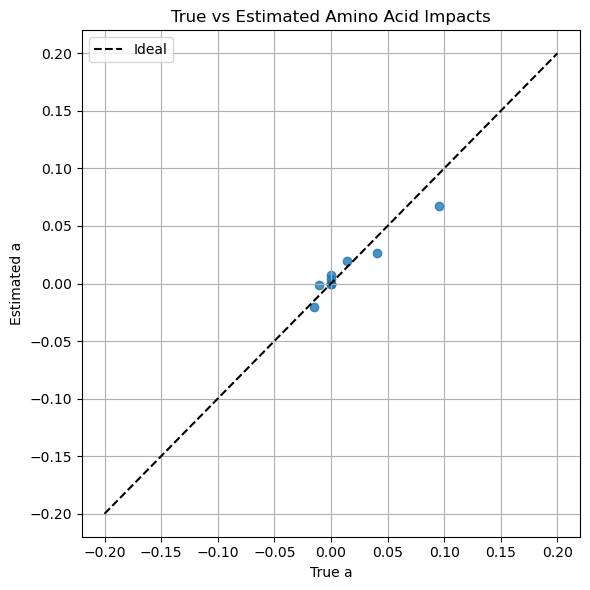

In [45]:
def plot_true_vs_est(true_a, est_a):
    plt.figure(figsize=(6, 6))
    plt.scatter(true_a, est_a, alpha=0.8)
    plt.plot([-0.2, 0.2], [-0.2, 0.2], 'k--', label='Ideal')
    plt.xlabel("True a")
    plt.ylabel("Estimated a")
    plt.title("True vs Estimated Amino Acid Impacts")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa=0.5, noise_level=0.1)
est_a = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=1)
plot_true_vs_est(data['true_a'], est_a)


- "#a6444f",  # reddish
- "#57a8b8",  # teal
- "#80557e",  # purple
- "#b5d2f2",  # light blue
- "#d991b4",  # pink
- "#397398",  # dark blue
- "#7394c2",  # mid blue
- "#7a7a7a"   # gray

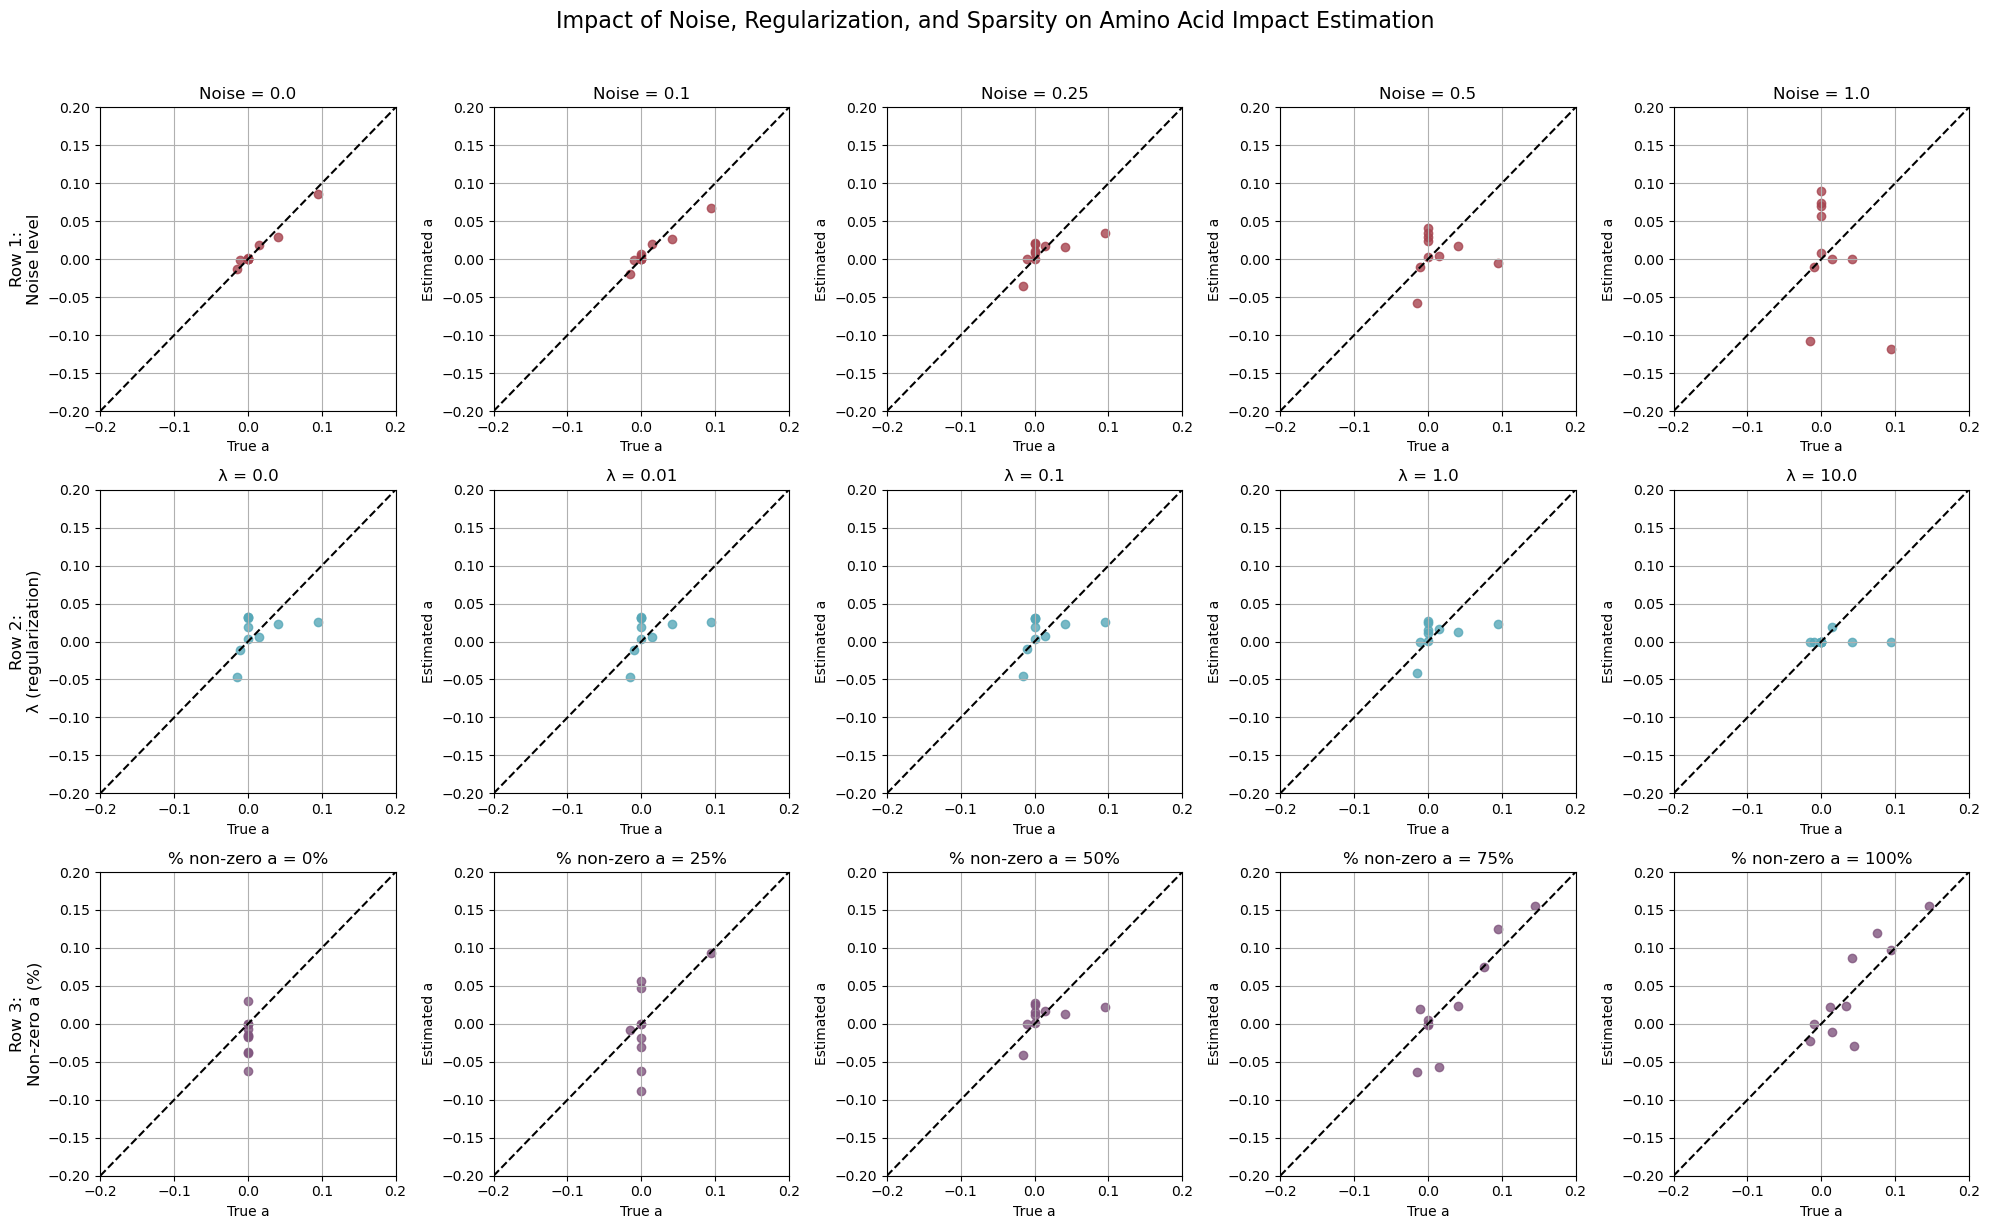

In [46]:
def plot_true_vs_est_subplot(ax, true_a, est_a, title="", color="blue"):
    ax.scatter(true_a, est_a, alpha=0.8, color=color)
    ax.plot([-0.2, 0.2], [-0.2, 0.2], 'k--', label='Ideal')
    ax.set_xlim(-0.2, 0.2)
    ax.set_ylim(-0.2, 0.2)
    ax.set_xlabel("True a")
    ax.set_ylabel("Estimated a")
    ax.set_title(title)
    ax.grid(True)

# --- Plot configuration ---
n_variants = 20
n_aachanges = 10
noise_levels = [0.0, 0.1, 0.25, 0.5, 1.0]
lambda_values = [0.0, 0.01, 0.1, 1.0, 10.0]
sparsity_levels = [0.0, 0.25, 0.5, 0.75, 1.0]
lambda_fixed = 1
noise_fixed = 0.3
percent_non0impact_aa_fixed = 0.5

# --- Subplots: 3 rows, 5 columns ---
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

# Row 1: Different noise levels
for i, noise in enumerate(noise_levels):
    data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa=percent_non0impact_aa_fixed, noise_level=noise)
    est_a = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=lambda_fixed)
    plot_true_vs_est_subplot(axes[0, i], data['true_a'], est_a, title=f"Noise = {noise}", color="#a6444f")

# Row 2: Different lambda values
for i, _lambda in enumerate(lambda_values):
    data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa=percent_non0impact_aa_fixed, noise_level=noise_fixed)
    est_a = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=_lambda)
    plot_true_vs_est_subplot(axes[1, i], data['true_a'], est_a, title=f"λ = {_lambda}", color = "#57a8b8")

# Row 3: Different sparsity levels (λ = 5)
for i, sparsity in enumerate(sparsity_levels):
    data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa=sparsity, noise_level=noise_fixed)
    est_a = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=lambda_fixed)
    plot_true_vs_est_subplot(axes[2, i], data['true_a'], est_a, title=f"% non-zero a = {int(100 * sparsity)}%", color="#80557e")

# Row labels
axes[0, 0].set_ylabel("Row 1:\nNoise level", fontsize=12)
axes[1, 0].set_ylabel("Row 2:\nλ (regularization)", fontsize=12)
axes[2, 0].set_ylabel("Row 3:\nNon-zero a (%)", fontsize=12)

fig.suptitle("Impact of Noise, Regularization, and Sparsity on Amino Acid Impact Estimation", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [15]:
# calculate mse
def calculate_mse(est_a, true_a):
    """
    Calculate the mean squared error between estimated and true amino acid impacts.
    """
    return np.mean((est_a - true_a) ** 2)

def calculate_mae(est_a, true_a):
    """
    Calculate the mean absolute error between estimated and true amino acid impacts.
    """
    return np.mean(np.abs(est_a - true_a))

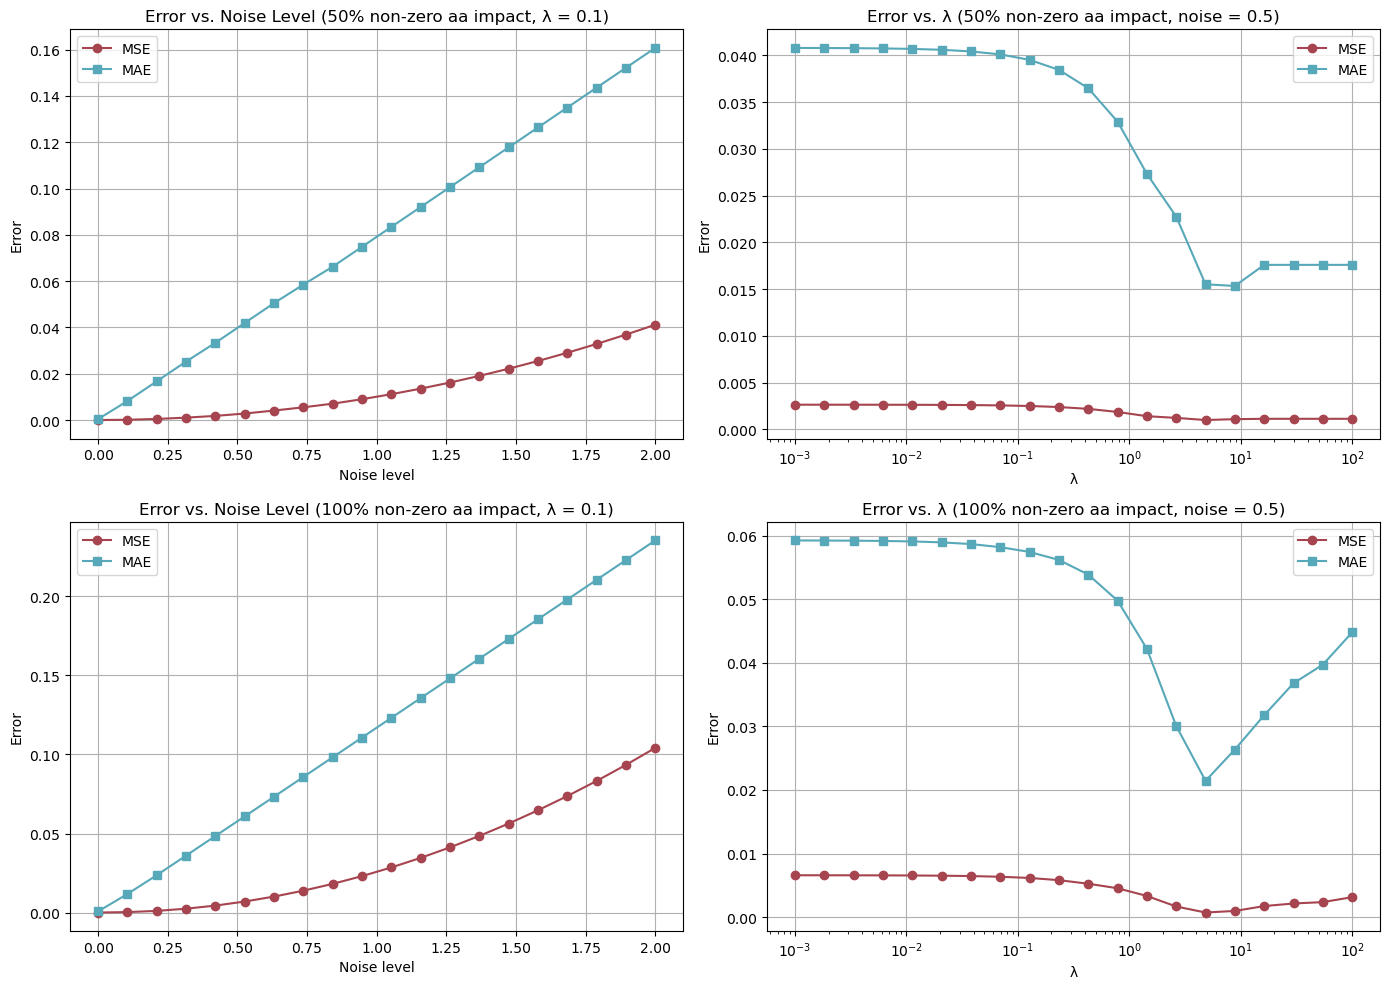

In [41]:
def sweep_metric_over_param(param_values, param_name, n_variants, n_aachanges, percent_non0impact_aa, fixed_lambda=None, fixed_noise=None):
    mses, maes = [], []

    for val in param_values:
        # Set either lambda or noise depending on the sweep
        noise_level = val if param_name == "noise" else fixed_noise
        _lambda = val if param_name == "lambda" else fixed_lambda

        data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa, noise_level)
        a_est = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=_lambda)

        mses.append(calculate_mse(a_est, data['true_a']))
        maes.append(calculate_mae(a_est, data['true_a']))

    return mses, maes

# --- Plot helper ---
def plot_error_curves(ax, x, mse, mae, title, xlabel, xscale='linear'):
    ax.plot(x, mse, marker='o', label='MSE', color= "#a6444f")
    ax.plot(x, mae, marker='s', label='MAE', color = "#57a8b8")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Error')
    ax.set_xscale(xscale)
    ax.legend()
    ax.grid(True)

# --- Experiment config ---
n_variants = 20
n_aachanges = 10
lambda_fixed = 0.1
noise_fixed = 0.5
noise_levels = np.linspace(0.0, 2.0, 20)
lambda_values = np.logspace(-3, 2, 20)

# --- Run sweeps ---
mses_noise_50, maes_noise_50 = sweep_metric_over_param(noise_levels, "noise", n_variants, n_aachanges, 0.5, fixed_lambda=lambda_fixed)
mses_lambda_50, maes_lambda_50 = sweep_metric_over_param(lambda_values, "lambda", n_variants, n_aachanges, 0.5, fixed_noise=noise_fixed)
mses_noise_100, maes_noise_100 = sweep_metric_over_param(noise_levels, "noise", n_variants, n_aachanges, 1.0, fixed_lambda=lambda_fixed)
mses_lambda_100, maes_lambda_100 = sweep_metric_over_param(lambda_values, "lambda", n_variants, n_aachanges, 1.0, fixed_noise=noise_fixed)

# --- Plot all ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_error_curves(axes[0, 0], noise_levels, mses_noise_50, maes_noise_50,
                  "Error vs. Noise Level (50% non-zero aa impact, λ = 0.1)", "Noise level")
plot_error_curves(axes[0, 1], lambda_values, mses_lambda_50, maes_lambda_50,
                  "Error vs. λ (50% non-zero aa impact, noise = 0.5)", "λ", xscale='log')
plot_error_curves(axes[1, 0], noise_levels, mses_noise_100, maes_noise_100,
                  "Error vs. Noise Level (100% non-zero aa impact, λ = 0.1)", "Noise level")
plot_error_curves(axes[1, 1], lambda_values, mses_lambda_100, maes_lambda_100,
                  "Error vs. λ (100% non-zero aa impact, noise = 0.5)", "λ", xscale='log')

plt.tight_layout()
plt.show()

In [32]:
# optimal lambda values

print(lambda_values[np.where(mses_lambda_50 == np.min(mses_lambda_50))[0][0]])
print(lambda_values[np.where(mses_lambda_100 == np.min(mses_lambda_100))[0][0]])

4.832930238571752
4.832930238571752


Playing around with the toy example, lambda seems to effect the result in a way, that mutation which doesn't have a value get growth rates closer to 0 with smaller errors on these but also non-zero effect aa substitutions get value further off from the truth. Approximately uniform accuracy over all substitutions is reached with lambda = 0.

Quite accurate results are gained when there is no noise in the data. However adding noise significantly worsens the result.

## Covid Data USA

In [49]:
url_pango_consensus_seq = "https://raw.githubusercontent.com/corneliusroemer/pango-sequences/refs/heads/main/data/pango-consensus-sequences_summary.json"
consensus_seq_df = pd.read_json(url_pango_consensus_seq)
consensus_seq_df

,A,A.1,A.2,A.2.2,A.2.3,A.2.4,A.2.5,A.2.5.1,A.2.5.2,A.2.5.3,...,XP,XQ,XR,XS,XT,XU,XV,XW,XY,XZ
lineage,A,A.1,A.2,A.2.2,A.2.3,A.2.4,A.2.5,A.2.5.1,A.2.5.2,A.2.5.3,...,XP,XQ,XR,XS,XT,XU,XV,XW,XY,XZ
unaliased,A,A.1,A.2,A.2.2,A.2.3,A.2.4,A.2.5,A.2.5.1,A.2.5.2,A.2.5.3,...,XP,XQ,XR,XS,XT,XU,XV,XW,XY,XZ
parent,,A,A,A.2,A.2,A.2,A.2,A.2.5,A.2.5,A.2.5,...,,,,,,,,,,
children,"[A.1, A.2, A.3, A.4, A.5, A.6, A.7, A.9, A.11,...",[],"[A.2.2, A.2.3, A.2.4, A.2.5]",[],[],[],"[A.2.5.1, A.2.5.2, A.2.5.3]",[],[],[],...,[],[],[],[],[],[],[],[],[],[]
nextstrainClade,19B,19B,19B,19B,19B,19B,19B,19B,19B,19B,...,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant
nucSubstitutions,"[A1T, C8782T, T28144C]","[A1T, C8782T, C17747T, A17858G, C18060T, T28144C]","[A1T, C8782T, T9477A, C14805T, G25979T, T28144...","[A1T, C4540T, C8782T, T9477A, C14805T, G25979T...","[A1T, C4540T, C8782T, T9477A, C14805T, C25714T...","[A1T, C8782T, T9477A, C12815T, C14805T, G25979...","[A1T, C275T, C1567T, C4543T, A5234G, A5488G, C...","[A1T, C275T, C1567T, C1722T, C4543T, A5234G, A...","[A1T, C275T, C1567T, C4543T, A5234G, A5488G, C...","[A1T, C275T, C1567T, G2272A, C4543T, A5234G, A...",...,"[C241T, C2470T, A2832G, C3037T, T5386G, G8393A...","[C21T, C241T, C2470T, A2832G, C3037T, C9344T, ...","[C21T, C241T, C2470T, A2832G, C3037T, C4893T, ...","[G210T, C241T, C3037T, G4181T, C5365T, C6196T,...","[C241T, T670G, C2790T, C3037T, G4184A, C4321T,...","[C241T, A2832G, C3037T, T5386G, G5924A, C9344T...","[C241T, A2832G, C3037T, C3583T, T5386G, G8393A...","[C241T, C2470T, A2832G, C3037T, G4184A, C4321T...","[C21T, C241T, A1585G, C2470T, A2832G, C3037T, ...","[C241T, T670G, C2790T, C3037T, G4184A, C4321T,..."
aaSubstitutions,[ORF8:L84S],"[ORF1b:P1427L, ORF1b:Y1464C, ORF8:L84S]","[N:S197L, ORF1a:F3071Y, ORF3a:G196V, ORF8:L84S]","[N:P13L, N:S197L, ORF1a:F3071Y, ORF3a:G196V, O...","[N:S197L, ORF1a:F3071Y, ORF3a:L108F, ORF3a:G19...","[N:S197L, ORF1a:F3071Y, ORF3a:G196V, ORF8:L84S]","[N:S197L, N:M234I, N:P383L, ORF1a:L4F, ORF1a:K...","[N:S197L, N:M234I, N:P365S, N:P383L, ORF1a:L4F...","[N:S197L, N:M234I, N:P383L, ORF1a:L4F, ORF1a:K...","[N:S197L, N:M234I, N:P383L, ORF1a:L4F, ORF1a:K...",...,"[E:T9I, M:D3G, M:Q19E, M:A63T, M:L120I, N:P13L...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:D3G, M:Q19E, M:A63T, N:P13L, N:R203K...","[E:T9I, M:D3G, M:Q19E, M:A63T, N:P13L, N:R203K...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:D3G, M:Q19E, M:A63T, N:P13L, N:R203K..."
nucDeletions,[],[],[],[],[],[],[21983-21991],[21983-21991],[21983-21991],[21983-21991],...,"[6513-6515, 11285-11293, 21765-21770, 21987-21...","[11288-11296, 21633-21641, 28362-28370, 29734-...","[11288-11296, 21633-21641, 28362-28370, 29734-...","[11285-11293, 21765-21770, 21987-21995, 28362-...","[11288-11296, 21633-21641, 28362-28370]","[6513-6515, 11288-11296, 21633-21641, 28362-28...","[6513-6515, 11285-11293, 28362-28370]","[11288-11296, 21633-21641, 28362-28370, 29734-...","[6513-6515, 11285-11293, 21633-21641, 28362-28...","[11288-11296, 21633-21641, 28362-28370]"
aaDeletions,[],[],[],[],[],[],"[S:L141-, S:G142-, S:V143-]","[S:L141-, S:G142-, S:V143-]","[S:L141-, S:G142-, S:V143-]","[S:L141-, S:G142-, S:V143-]",...,"[N:E31-, N:R32-, N:S33-, ORF1a:S2083-, ORF1a:L...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G...","[N:E31-, N:R32-, N:S33-, ORF1a:L3674-, ORF1a:S...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G...","[N:E31-, N:R32-, N:S33-, ORF1a:S2083-, ORF1a:S...","[N:E31-, N:R32-, N:S33-, ORF1a:S2083-, ORF1a:L...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G...","[N:E31-, N:R32-, N:S33-, ORF1a:S2083-, ORF1a:L...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G

In [50]:
# work with aaSubstitutionsNew

# Get all unique substitutions
substitutions = sorted(set(sub for sublist in consensus_seq_df.loc['aaSubstitutionsNew'] for sub in sublist))
if(substitutions[0] == ''):
    substitutions.remove('')


def row_to_binary(sub_list):
    return pd.Series([1 if sub in sub_list else 0 for sub in substitutions], index=substitutions)

# Step 4: apply to each lineage (i.e., each column of the original row)
substitutions_df = consensus_seq_df.loc['aaSubstitutionsNew'].apply(row_to_binary)
W = substitutions_df.to_numpy()
substitutions_df

,E:A41V,E:D72G,E:E8D,E:F20L,E:F23V,E:F26L,E:L18I,E:L21F,E:L51I,E:L73F,...,S:Y248N,S:Y248S,S:Y265C,S:Y269N,S:Y28H,S:Y449H,S:Y449N,S:Y451H,S:Y453F,S:Y505H
A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.2.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.2.3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XU,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
XV,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
XW,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
XY,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [51]:
# get vector of growth rate differences of child to parent pango lineages

pango_clade_mapping = pd.read_csv('data/covid_results/pango_clade_mapping_window300_pivotA5.csv')
pango_clade_mapping = pango_clade_mapping.rename(columns={"seqName": "lineage"})

parent_df = pd.DataFrame(consensus_seq_df.loc['parent'].values, columns=['parent'], index=consensus_seq_df.loc['lineage']).reset_index()
pango_clade_mapping = pango_clade_mapping.merge(parent_df, on="lineage", how="left")

# some lineages have negative growth advantage compared to their parent
pango_clade_mapping['parent_growth_advantage'] = pango_clade_mapping['pango_growth'] - pango_clade_mapping['parent'].map(pango_clade_mapping.set_index('lineage')['pango_growth'])

pango_clade_mapping

,lineage,clade,pango_growth,clade_growth,pango_lif,clade_lif,pango_time,clade_time,parent,parent_growth_advantage
0,A.5,19B,0.000000,0.000000,0.000000,0.000000,45.181818,150.199306,A,-0.104699
1,A.1,19B,0.061626,0.000000,2.655418,0.000000,59.252306,150.199306,A,-0.043073
2,A.3,19B,0.069903,0.000000,1.155658,0.000000,63.350183,150.199306,A,-0.034796
3,A.2,19B,0.096689,0.000000,-3.888758,0.000000,107.638889,150.199306,A,-0.008009
4,A,19B,0.104699,0.000000,-3.548262,0.000000,156.554386,150.199306,,NaN
...,...,...,...,...,...,...,...,...,...,...
2985,NY.1,25A,1.085404,0.711105,-990.380803,-660.436942,1843.843750,1837.413845,LP.8.1.1,-0.002543
2986,NY.3,25A,1.085721,0.711105,-989.395070,-660.436942,1844.103896,1837.413845,LP.8.1.1,-0.002225
2987,LP.8.1.1,25A,1.087947,0.711105,-990.545404,-660.436942,1845.879013,1837.413845,LP.8.1,0.018683
2988,NW.1,25A,1.098315,0.711105,-1013.497309,-660.436942,1853.132353,1837.413845,LP.8.1.2,0.035350


In [52]:
# variants without parent growth rate
np.isnan(pango_clade_mapping['parent_growth_advantage']).sum()

np.int64(50)

- Only variants that have been sequenced at least once (in the US) are considered in the growth rate estimation, this looses 197 from the pango-clade-mapping dataframe
- only pango lineages are kept that are part of the pango clade mapping dataframe, this looses 118 lineages
- also consensus_seq_df contains more variants than included in the growth rate estimation (1378) and 3 can't be looked up.

For now, I'll include only pango lineages, that are present in all three dataframes and whoose parents have a growth rate estimate


#### Calculate covariance matrix

$$
d_i = s_c^{(i)} - s_p^{(i)} = (D \cdot s)_i
$$

$$
Cov(d) = Cov (D \cdot s) = D \cdot Cov(s) \cdot D^T
$$

In [48]:
hess_inv = np.loadtxt('data/covid_results/inv_hessian_window300_pivotA5', delimiter=',')
lineage_names = np.loadtxt('data/covid_results/variant_names_pivotA5', delimiter=',', dtype=str)

In [102]:
#df_inv_hess = pd.DataFrame(hess_inv_augmented, index=lineage_names, columns=lineage_names)

In [66]:
def calculate_fitness_advantage_covariance(hess_inv, lineage_names, pango_clade_mapping):
    """
    Calculate the covariance of fitness advantage between child and parent lineages.
    """
    # only work with growth rates here and add 0 variance and covariance for pivot
    n = hess_inv.shape[0] // 2
    hess_inv = hess_inv[: n, : n]
    hess_inv_augmented = np.zeros((n + 1, n + 1))
    hess_inv_augmented[1:, 1:] = hess_inv
    n = n + 1
    
    # Create a mapping from lineage names to indices
    name_to_index = {name: idx for idx, name in enumerate(lineage_names)}

    # drop rows where growth advsantage hasn't been estimated for parent (50 lineages droped, including A)
    pango_clade_mapping_with_parent = pango_clade_mapping.dropna(subset=['parent_growth_advantage'])
    
    # Initialize the covariance matrix
    m = len(pango_clade_mapping_with_parent)
    D = np.zeros((m, n))
    
    # Iterate through each row in the PANGO clade mapping
    for i, (_, row) in enumerate(pango_clade_mapping_with_parent.iterrows()):
        child = row['lineage']
        parent = row['parent']
        
        D[i, name_to_index[child]] = 1
        D[i, name_to_index[parent]] = -1
    
    child_parent_covariance = D @ hess_inv_augmented @ D.T
    return child_parent_covariance

In [70]:
C = calculate_fitness_advantage_covariance(hess_inv, lineage_names, pango_clade_mapping)
C_ = np.diag(np.diag(C))    # reduced complexity: only consider variance

## Estimate Amino Acid Substitution Impact

In [85]:
pango_clade_mapping_with_parent = pango_clade_mapping.dropna(subset=['parent_growth_advantage'])
lineage_names = pango_clade_mapping_with_parent.lineage.values

W = substitutions_df.loc[lineage_names].values # we know aa substitutions for all vairants with growth rate advantages

In [93]:
delta_s = pango_clade_mapping.dropna(subset=['parent_growth_advantage']).parent_growth_advantage.values
aa_impact_C = estimate_aa_impact(delta_s, C, W, _lambda=0.1)
aa_impact = estimate_aa_impact(delta_s, C_, W, _lambda=0.1)

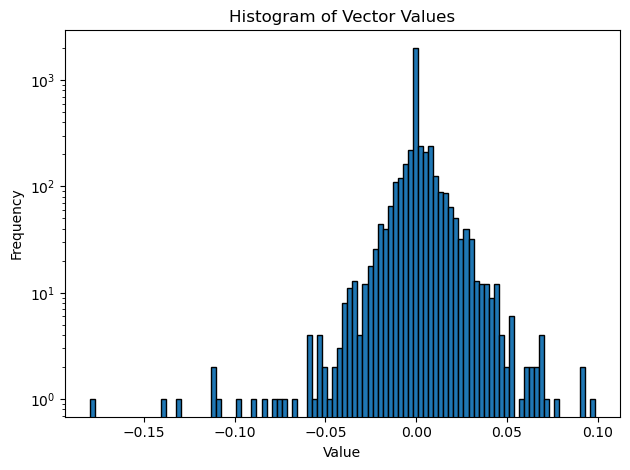

In [94]:
# Create histogram
plt.hist(aa_impact, bins=100, edgecolor='black')

# Label axes
plt.xlabel("Value")
plt.yscale('log') 
plt.ylabel("Frequency")
plt.title("Histogram of Vector Values")

# Show plot
plt.tight_layout()
plt.show()

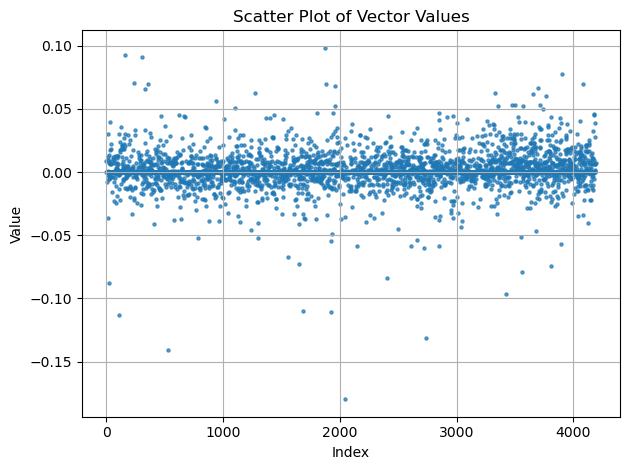

In [95]:
plt.scatter(range(len(aa_impact)), aa_impact, alpha=0.7, s = 5)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Scatter Plot of Vector Values")
plt.grid(True)
plt.tight_layout()
plt.show()
